In [2]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd
import numpy as np

# Data Collection

In [3]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "1h", 
    days = 1825,
    limit = 1000
)
df = data_collector.collect_data()

In [4]:
df.head()

,timestamp,open,high,low,close,volume
0,2020-10-29 05:00:00,13235.95,13291.82,13235.95,13284.83,2327.250401
1,2020-10-29 06:00:00,13284.84,13326.39,13244.96,13278.72,2834.696947
2,2020-10-29 07:00:00,13278.72,13290.80,13120.88,13138.87,2827.277106
3,2020-10-29 08:00:00,13138.87,13188.15,13081.00,13123.96,2561.360486
4,2020-10-29 09:00:00,13123.96,13208.77,13120.00,13190.11,2498.113915


In [5]:
df.tail()

,timestamp,open,high,low,close,volume
43775,2025-10-28 00:00:00,114107.65,114374.20,113788.32,113961.67,554.91770
43776,2025-10-28 01:00:00,113961.67,114547.20,113961.67,114424.76,485.50547
43777,2025-10-28 02:00:00,114424.76,114474.10,113569.91,113936.94,686.42190
43778,2025-10-28 03:00:00,113936.93,114109.86,113717.00,113908.24,457.29772
43779,2025-10-28 04:00:00,113908.25,113940.00,113852.50,113912.80,20.48653


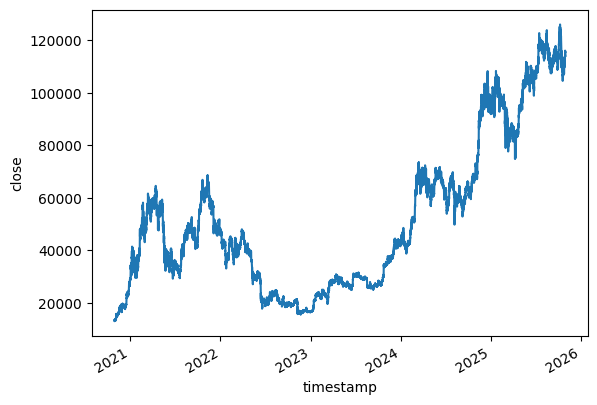

In [6]:
sns.lineplot(x="timestamp", y="close", data=df)
plt.gcf().autofmt_xdate()
plt.show()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43780 entries, 0 to 43779
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  43780 non-null  datetime64[ns]
 1   open       43780 non-null  float64       
 2   high       43780 non-null  float64       
 3   low        43780 non-null  float64       
 4   close      43780 non-null  float64       
 5   volume     43780 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 2.0 MB


In [8]:
df.describe()

,timestamp,open,high,low,close,volume
count,43780,43780.000000,43780.000000,43780.000000,43780.000000,43780.000000
mean,2023-04-30 00:14:57.204203008,51755.588215,51961.829264,51541.122293,51757.888520,3203.927308
min,2020-10-29 05:00:00,13051.680000,13145.360000,12920.770000,13052.060000,0.000000
25%,2022-01-29 00:45:00,27930.597500,28020.627500,27857.887500,27930.810000,799.246548
50%,2023-04-30 02:30:00,43474.530000,43677.995000,43264.945000,43475.930000,1588.405903
75%,2024-07-29 03:15:00,66095.455000,66354.520000,65821.757500,66100.117500,3504.658018
max,2025-10-28 04:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600
std,NaN,29127.887504,29201.568173,29053.360474,29128.820254,4725.009591


# Technical Indicators

### Momentum

In [9]:
##Awesome Oscillator (AO)
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()

##KAMA
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

## PPO
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

## PVO
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

## ROC
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

## RSI
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

## STOCHASTIC RSI
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

## STOCHASTIC OSCILLATOR
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

## TSI
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

### Volume

In [10]:
## ADI
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

## CMF
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

##EoM EMV
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()

##FI
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

##MFI
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

##NVI
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

##OBV
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

##VPT
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

## VWAP
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

### Volatility

In [11]:
## ATR
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

## BBANDS
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

## DONCHIAN CHANNEL
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

## KELTNER CHANNEL
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

## Ulcer Index
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

### Trend

In [12]:
## ADX
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

## AROON
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

## CCI
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

## DPO
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

## EMA
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

## KST
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

## MACD
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

## MI
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

## SMA
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

## VI
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

## WMA
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

# Data Cleaning

In [13]:
dataset = df.copy()
data_cleaning = DataCleaning()
dataset = data_cleaning.dropna(dataset)
dataset = data_cleaning.drop_duplicates(dataset)

In [14]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
40,2020-10-30 21:00:00,13625.94,13638.29,13466.00,13547.45,2112.027067,130.303647,13499.095141,0.409301,0.192196,...,85.613628,54.952496,29.124504,25.827992,24.348337,13424.110000,1.203683,0.781189,0.422493,13486.372000
41,2020-10-30 22:00:00,13547.45,13600.00,13529.00,13553.09,1144.799593,124.432206,13503.925587,0.421584,0.163584,...,86.070598,56.641312,34.627865,22.013446,24.351345,13446.296429,1.206826,0.841182,0.365644,13503.569333
42,2020-10-30 23:00:00,13553.10,13637.00,13535.05,13560.10,1434.184391,125.228088,13513.371536,0.430494,0.137995,...,86.395565,57.878175,39.277927,18.600247,24.330068,13466.514286,1.242800,0.787798,0.455002,13518.743143
43,2020-10-31 00:00:00,13560.10,13648.00,13511.45,13615.06,1793.382087,132.439265,13529.024925,0.464969,0.137976,...,86.597191,62.571920,43.936726,18.635194,24.394157,13488.902857,1.187405,0.807327,0.380078,13538.549238
44,2020-10-31 01:00:00,13615.27,13657.16,13571.30,13636.14,1432.405584,131.755735,13534.877749,0.499001,0.137607,...,86.381741,67.217881,48.592957,18.624924,24.190950,13509.499286,1.207056,0.816426,0.390630,13558.180857


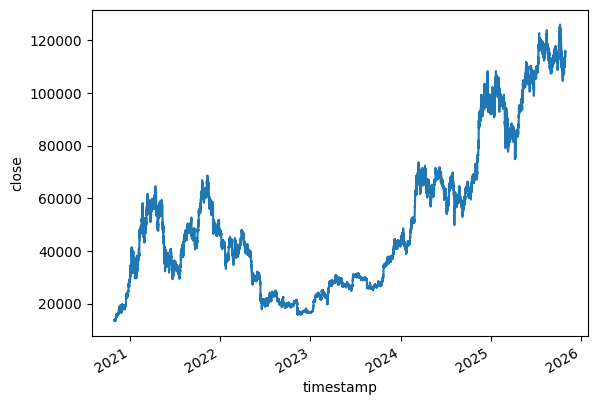

In [15]:
sns.lineplot(x="timestamp", y="close", data=dataset)
plt.gcf().autofmt_xdate()
plt.show()

In [16]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
40,2020-10-30 21:00:00,13625.94,13638.29,13466.00,13547.45,2112.027067,130.303647,13499.095141,0.409301,0.192196,...,85.613628,54.952496,29.124504,25.827992,24.348337,13424.110000,1.203683,0.781189,0.422493,13486.372000
41,2020-10-30 22:00:00,13547.45,13600.00,13529.00,13553.09,1144.799593,124.432206,13503.925587,0.421584,0.163584,...,86.070598,56.641312,34.627865,22.013446,24.351345,13446.296429,1.206826,0.841182,0.365644,13503.569333
42,2020-10-30 23:00:00,13553.10,13637.00,13535.05,13560.10,1434.184391,125.228088,13513.371536,0.430494,0.137995,...,86.395565,57.878175,39.277927,18.600247,24.330068,13466.514286,1.242800,0.787798,0.455002,13518.743143
43,2020-10-31 00:00:00,13560.10,13648.00,13511.45,13615.06,1793.382087,132.439265,13529.024925,0.464969,0.137976,...,86.597191,62.571920,43.936726,18.635194,24.394157,13488.902857,1.187405,0.807327,0.380078,13538.549238
44,2020-10-31 01:00:00,13615.27,13657.16,13571.30,13636.14,1432.405584,131.755735,13534.877749,0.499001,0.137607,...,86.381741,67.217881,48.592957,18.624924,24.190950,13509.499286,1.207056,0.816426,0.390630,13558.180857


# Feature Engineering

### Timestamp Features

In [17]:
dataset["hour"] = dataset['timestamp'].dt.hour
dataset['dayofweek'] = dataset['timestamp'].dt.dayofweek
dataset['quarter'] = dataset['timestamp'].dt.quarter
dataset['month'] = dataset['timestamp'].dt.month
dataset['year'] = dataset['timestamp'].dt.year
dataset['dayofyear'] = dataset['timestamp'].dt.dayofyear
dataset['dayofmonth'] = dataset['timestamp'].dt.day

In [18]:
dataset.tail()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
43775,2025-10-28 00:00:00,114107.65,114374.20,113788.32,113961.67,554.91770,-409.055765,114791.195269,0.022260,-0.216321,...,1.152753,-0.325872,114624.935905,0,1,4,10,2025,301,28
43776,2025-10-28 01:00:00,113961.67,114547.20,113961.67,114424.76,485.50547,-513.196294,114779.847595,0.008270,-0.184249,...,1.124524,-0.272496,114568.238571,1,1,4,10,2025,301,28
43777,2025-10-28 02:00:00,114424.76,114474.10,113569.91,113936.94,686.42190,-599.634853,114652.861677,-0.036769,-0.183430,...,1.115388,-0.286676,114455.424857,2,1,4,10,2025,301,28
43778,2025-10-28 03:00:00,113936.93,114109.86,113717.00,113908.24,457.29772,-690.755882,114493.974075,-0.073667,-0.176263,...,1.165485,-0.273157,114349.534286,3,1,4,10,2025,301,28
43779,2025-10-28 04:00:00,113908.25,113940.00,113852.50,113912.80,20.48653,-725.312824,114387.263619,-0.101445,-0.163232,...,1.198983,-0.290404,114257.166381,4,1,4,10,2025,301,28


In [19]:
dataset = data_cleaning.dropna(dataset)
dataset = data_cleaning.drop_duplicates(dataset)

# Feature Selection

In [20]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [21]:
dataset = dataset.sort_values('timestamp')

In [22]:
X_close = dataset.drop(['timestamp', 'close'], axis=1)
y_close = dataset['close']

### Feature Importance

In [23]:
xgb_close = XGBRegressor(
    device='cuda',
    max_bin=256,
    eval_metric='rmse',
)

In [24]:
tscv = TimeSeriesSplit(n_splits=100)

##### Train the model

In [25]:
## Train the model
def model_training(X, y, model, tscv):
    fold_metrics = []
    n = len(X)
    oof_pred = np.full(shape=n, fill_value=np.nan, dtype=float)
    feature_names = X.columns.tolist()
    fold_id = 0
    gain_accum = pd.Series(0.0, index=feature_names)

    for train_idx, val_idx in tscv.split(X):
        fold_id += 1
        X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False,
        )

        # OOF predictions for this fold’s validation window
        y_val_pred = model.predict(X_test)
        oof_pred[val_idx] = y_val_pred

        # Fold metrics
        rmse = root_mean_squared_error(y_test, y_val_pred)
        mae  = mean_absolute_error(y_test, y_val_pred)
        fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae})

        # Gain importances for this fold (reindexed to all features, missing -> 0)
        gain_dict = model.get_booster().get_score(importance_type="gain")
        gain_fold = pd.Series(gain_dict, dtype=float)

        # xgboost keys are the raw feature names; ensure alignment
        gain_fold.index = [k for k in gain_fold.index]  # no-op but explicit
        gain_fold = gain_fold.reindex(feature_names).fillna(0.0)
        gain_accum += gain_fold

    return fold_metrics, oof_pred, gain_accum


### Get most value variables

In [26]:
features_by_target = {}
fold_metrics, oof_pred, gain_accum = model_training(X_close, y_close, xgb_close, tscv)
importance_df = (
    gain_accum.div(100)             # average gain across folds
    .sort_values(ascending=False)
    .rename("avg_gain")
    .reset_index()
    .rename(columns={"index": "feature"})
)
importance_df["gain_pct"] = (importance_df["avg_gain"] / importance_df["avg_gain"].sum()) * 100
features_by_target["close"] = importance_df[importance_df["gain_pct"] > 0.5]["feature"].tolist()

c:\Users\DG\Desktop\trading-bot-project\data_analysis_trading_bot\venv\Lib\site-packages\xgboost\core.py:729: UserWarning: [22:03:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [27]:
features_by_target

{'close': ['high',
  'low',
  'DONCHIAN_HIGH',
  'VWAP',
  'BBANDS_HIGH',
  'SMA',
  'DONCHIAN_LOW',
  'KAMA',
  'BBANDS_LOWER',
  'DONCHIAN_MIDDLE',
  'WMA',
  'ADI',
  'EMA',
  'open']}

In [28]:
all_features = features_by_target["close"] + ["close"]

### Save Selected Features

In [29]:
import os
import json
from datetime import datetime
model_folder = "saved_models"
os.makedirs(model_folder, exist_ok=True)

In [30]:
with open('feature_selection/features_by_target_1h_lstm.json', 'w') as f:
    json.dump(features_by_target, f, indent=4)

# Scale Data

In [31]:
from sklearn.preprocessing import MinMaxScaler

In [32]:
dataset.drop(['timestamp'], axis=1, inplace=True)

In [33]:
dataset.head()

,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
40,13625.94,13638.29,13466.00,13547.45,2112.027067,130.303647,13499.095141,0.409301,0.192196,0.217105,...,0.781189,0.422493,13486.372000,21,4,4,10,2020,304,30
41,13547.45,13600.00,13529.00,13553.09,1144.799593,124.432206,13503.925587,0.421584,0.163584,0.258000,...,0.841182,0.365644,13503.569333,22,4,4,10,2020,304,30
42,13553.10,13637.00,13535.05,13560.10,1434.184391,125.228088,13513.371536,0.430494,0.137995,0.292499,...,0.787798,0.455002,13518.743143,23,4,4,10,2020,304,30
43,13560.10,13648.00,13511.45,13615.06,1793.382087,132.439265,13529.024925,0.464969,0.137976,0.326993,...,0.807327,0.380078,13538.549238,0,5,4,10,2020,305,31
44,13615.27,13657.16,13571.30,13636.14,1432.405584,131.755735,13534.877749,0.499001,0.137607,0.361395,...,0.816426,0.390630,13558.180857,1,5,4,10,2020,305,31


In [34]:
scaler = MinMaxScaler(feature_range= (0, 1))

In [35]:
scaled_data = scaler.fit_transform(dataset[all_features])

In [36]:
scaled_data

array([[1.92448233e-03, 2.41795097e-03, 0.00000000e+00, ...,
        0.00000000e+00, 2.91331278e-03, 2.21703464e-03],
       [1.58496691e-03, 2.98016138e-03, 0.00000000e+00, ...,
        1.00565558e-04, 2.21694612e-03, 2.26707296e-03],
       [1.91304397e-03, 3.03415143e-03, 0.00000000e+00, ...,
        1.96110286e-04, 2.26707316e-03, 2.32926598e-03],
       ...,
       [8.96030338e-01, 8.95742720e-01, 9.12917699e-01, ...,
        9.06886845e-01, 8.97204783e-01, 8.92876832e-01],
       [8.92800641e-01, 8.97055347e-01, 9.07497065e-01, ...,
        9.06150492e-01, 8.92876734e-01, 8.92622205e-01],
       [8.91294502e-01, 8.98264546e-01, 9.07497065e-01, ...,
        9.05517776e-01, 8.92622284e-01, 8.92662661e-01]],
      shape=(43712, 15))

# Splitting the data

In [37]:
train_size = int(len(dataset)*.80)
test_size = len(dataset) - train_size

In [38]:
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size-60:]

In [39]:
train_data.shape, test_data.shape

((34969, 15), (8803, 15))

# Creating training set

In [40]:
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i])
    y_train.append(train_data[i, 3])  # Assuming 'close' is the 4th column in all_features

In [41]:
x_train, y_train = np.array(x_train), np.array(y_train)

In [42]:
x_train.shape , y_train.shape

((34909, 60, 15), (34909,))

# LSTM Models

In [43]:

import keras
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

In [44]:
model = Sequential([
    LSTM(50, return_sequences= True, input_shape= (x_train.shape[1], x_train.shape[2])),
    LSTM(64, return_sequences= False),
    Dense(32),
    Dense(16),
    Dense(1)
])

model.compile(optimizer= 'adam', loss= 'mse' , metrics=['mean_absolute_error'])

c:\Users\DG\Desktop\trading-bot-project\data_analysis_trading_bot\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        13,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,265 (176.82 KB)

 Trainable params: 45,265 (176.82 KB)

 Non-trainable params: 0 (0.00 B)

### Model training

In [46]:
from keras.callbacks import EarlyStopping

In [59]:
# Fitting the LSTM to the Training set
callbacks = [EarlyStopping(monitor= 'loss', patience= 10 , restore_best_weights= True)]
history = model.fit(x_train, y_train, epochs= 100, batch_size= 32 , callbacks= callbacks )

Epoch 1/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - loss: 1.1939e-05 - mean_absolute_error: 0.0014
Epoch 2/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - loss: 1.8807e-06 - mean_absolute_error: 9.7352e-04
Epoch 3/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - loss: 2.6591e-06 - mean_absolute_error: 0.0011
Epoch 4/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - loss: 2.6571e-06 - mean_absolute_error: 0.0012
Epoch 5/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - loss: 2.7523e-06 - mean_absolute_error: 0.0011
Epoch 6/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - loss: 2.1957e-06 - mean_absolute_error: 0.0010
Epoch 7/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - loss: 2.0373e-06 - mean_absolute_error: 0.0010
Epoch 8/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - loss: 2.8973e-06 - mean_absolute_error: 0.0012
Epoch 9/100
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - loss: 1.8175e-06 - mean_absolute_error: 9.4392e-04
Epoch 10/100
1091/1091 ━━━━━━━━━━━━━━━

# Model Evaluation

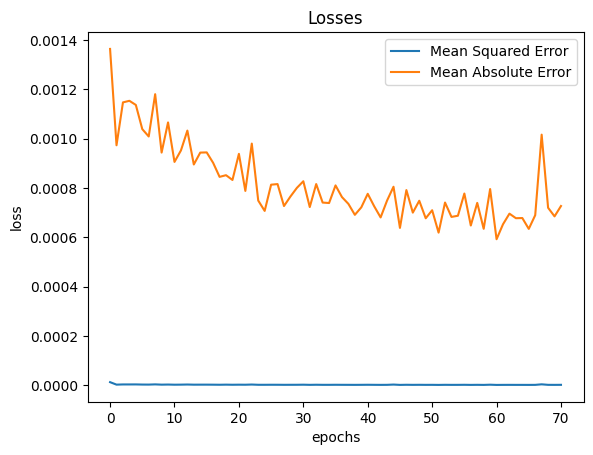

In [60]:
plt.plot(history.history["loss"])
plt.plot(history.history["mean_absolute_error"])
plt.legend(['Mean Squared Error','Mean Absolute Error'])
plt.title("Losses")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

# Prediction

In [61]:
x_test = []
y_test = []

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i])
    y_test.append(test_data[i, 3])



In [62]:
x_test = np.array(x_test)

In [63]:
y_test = np.array(y_test)

In [64]:
x_test.shape , y_test.shape


((8743, 60, 15), (8743,))

In [65]:
#inverse y_test scaling
predictions = model.predict(x_test)

274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [98]:
pred_temp = np.zeros((predictions.shape[0], 15))
pred_temp[:,0] = predictions[:,0]  # 0 es la columna Close

predictions_real = scaler.inverse_transform(pred_temp)
predictions_real = predictions_real[:,0]  # nos quedamos solo con Close

In [99]:
y_temp = np.zeros((y_test.shape[0], 15))
y_temp[:,0] = y_test
y_test_real = scaler.inverse_transform(y_temp)[:,0]

In [100]:
RMSE = np.sqrt(np.mean((y_test_real - predictions_real)**2))
print("Test RMSE:", round(RMSE, 2))

Test RMSE: 4254.86


In [101]:
train = dataset.iloc[:train_size]
test = dataset.iloc[train_size:]

test = test.copy()  # para evitar el famoso Warning de pandas
test['Predictions'] = predictions_real

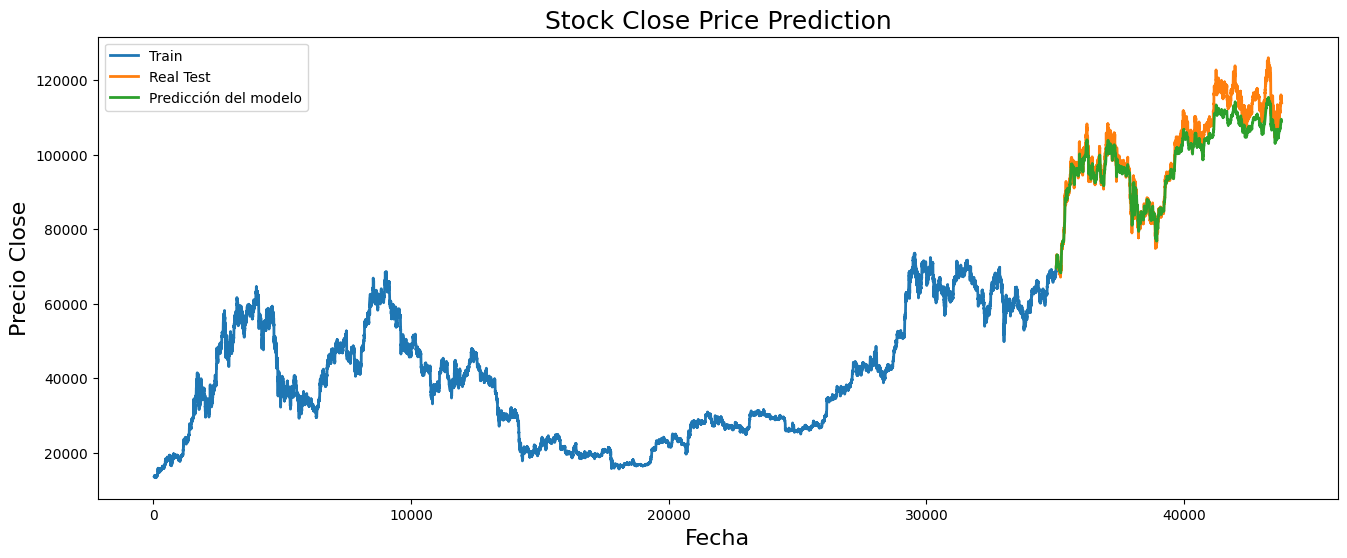

In [102]:
plt.figure(figsize=(16,6))
plt.title('Stock Close Price Prediction', fontsize=18)
plt.xlabel('Fecha', fontsize=16)
plt.ylabel('Precio Close', fontsize=16)

plt.plot(train.index, train['close'], linewidth=2)
plt.plot(test.index, test['close'], linewidth=2)
plt.plot(test.index, test['Predictions'], linewidth=2)

plt.legend(['Train', 'Real Test', 'Predicción del modelo'])
plt.show()

# Predict next 24 hours

In [103]:
from datetime import timedelta

In [104]:
def insert_end(Xin, new_input):
    timestep = 60
    for i in range(timestep - 1):
        Xin[:, i, :] = Xin[:, i+1, :]
    Xin[:, timestep - 1, :] = new_input
    return Xin

In [112]:
df["timestamp"] = pd.to_datetime(df["timestamp"])  # ensure correct type
last_time = df["timestamp"].iloc[-1]

In [120]:
future = 24
forecast = []
Xin = x_test[-1:, :, :]
time = []

for i in range(future):
    out = model.predict(Xin, batch_size=5)
    forecast.append(out[0,0])

    new_step = Xin[:, -1, :].copy()
    new_step[:,0] = out[0,0]
    Xin = insert_end(Xin, new_step)

    time.append(last_time + timedelta(hours=i))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [121]:
time

[Timestamp('2025-10-28 04:00:00'),
 Timestamp('2025-10-28 05:00:00'),
 Timestamp('2025-10-28 06:00:00'),
 Timestamp('2025-10-28 07:00:00'),
 Timestamp('2025-10-28 08:00:00'),
 Timestamp('2025-10-28 09:00:00'),
 Timestamp('2025-10-28 10:00:00'),
 Timestamp('2025-10-28 11:00:00'),
 Timestamp('2025-10-28 12:00:00'),
 Timestamp('2025-10-28 13:00:00'),
 Timestamp('2025-10-28 14:00:00'),
 Timestamp('2025-10-28 15:00:00'),
 Timestamp('2025-10-28 16:00:00'),
 Timestamp('2025-10-28 17:00:00'),
 Timestamp('2025-10-28 18:00:00'),
 Timestamp('2025-10-28 19:00:00'),
 Timestamp('2025-10-28 20:00:00'),
 Timestamp('2025-10-28 21:00:00'),
 Timestamp('2025-10-28 22:00:00'),
 Timestamp('2025-10-28 23:00:00'),
 Timestamp('2025-10-29 00:00:00'),
 Timestamp('2025-10-29 01:00:00'),
 Timestamp('2025-10-29 02:00:00'),
 Timestamp('2025-10-29 03:00:00')]

# Create Dataframe

In [122]:
# Convert to array
forcast = np.array(forcast).reshape(-1,1)

# Inverse transform Close only
future_temp = np.zeros((future, 15))
future_temp[:,0] = forcast[:,0]
forecast_real = scaler.inverse_transform(future_temp)[:,0]

print("Forecasted Closing Prices:")
print(forecast_real)

Forecasted Closing Prices:
[89104.4703793  89104.45021296 89104.43676873 89104.40315815
 89104.41660238 89104.40315815 89104.40315815 89104.38971392
 89104.38299181 89104.38971392 89104.38971392 89104.36954758
 89104.38299181 89104.37626969 89104.37626969 89104.36282546
 89104.34938123 89104.35610335 89104.35610335 89104.34938123
 89104.35610335 89104.35610335 89104.34938123 89104.34938123]


In [123]:
forcasted_output = pd.DataFrame(forecast_real)
date = pd.DataFrame(time)
df_result = pd.concat([date,forcasted_output], axis=1)
df_result.columns = "Date", "Forecasted"

In [124]:
df_result

,Date,Forecasted
0,2025-10-28 04:00:00,89104.470379
1,2025-10-28 05:00:00,89104.450213
2,2025-10-28 06:00:00,89104.436769
3,2025-10-28 07:00:00,89104.403158
4,2025-10-28 08:00:00,89104.416602
5,2025-10-28 09:00:00,89104.403158
6,2025-10-28 10:00:00,89104.403158
7,2025-10-28 11:00:00,89104.389714
8,2025-10-28 12:00:00,89104.382992
9,2025-10-28 13:00:00,89104.389714


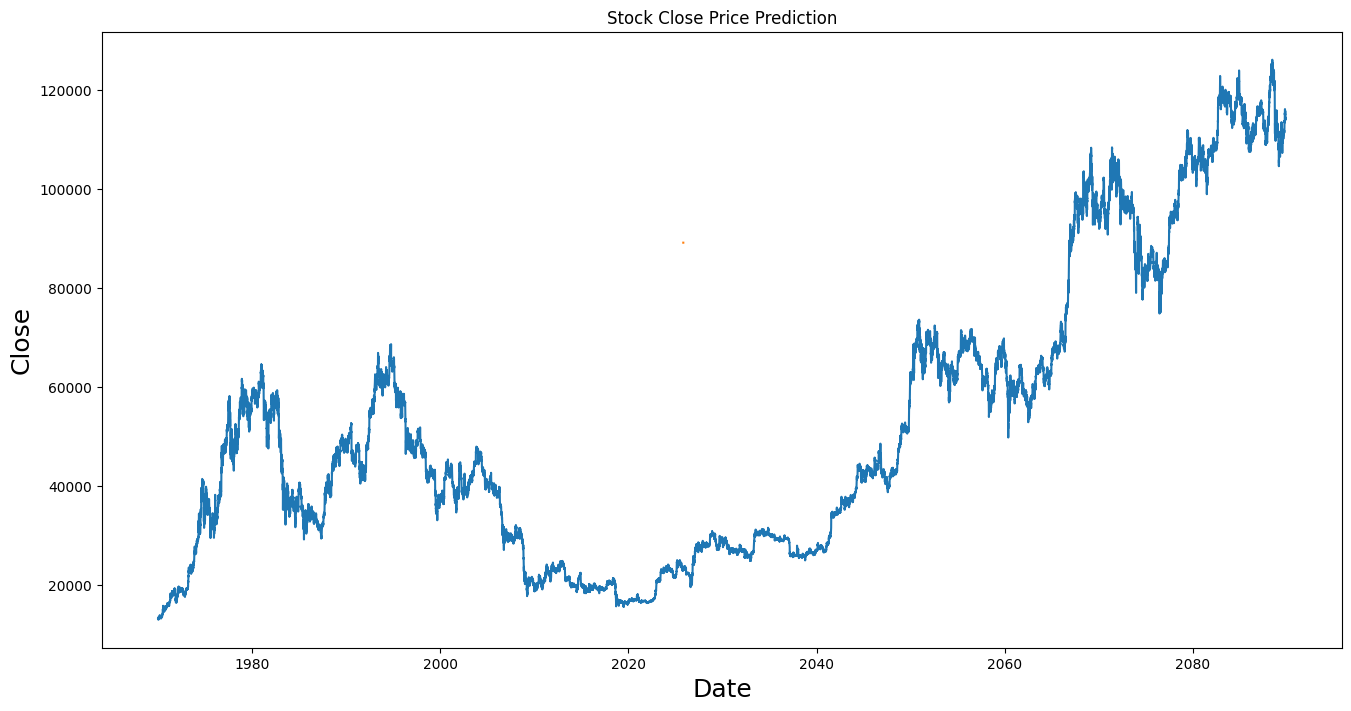

In [125]:
plt.figure(figsize=(16, 8))
plt.title('Stock Close Price Prediction')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close' ,fontsize=18)
plt.plot(df['close'])
plt.plot(df_result.set_index('Date')[['Forecasted']])